# Master Bias Creation

This notebook creates a master bias frame from 10 raw zero exposures obtained
with the Tek2K_3 CCD detector at the CTIO 0.9 m telescope.

The detector was read using two amplifiers. Each amplifier contains its own
overscan region, which is used to estimate and remove the electronic offset
before trimming the images to the useful detector area.

The processing steps are:

1. Load the raw bias frames.
2. Correct each amplifier using its overscan region.
3. Trim the non-science pixels.
4. Reconstruct the 2048 × 2048 detector image.
5. Combine the 10 corrected bias frames using the median.

In [19]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.stats import sigma_clipped_stats, mad_std

In [2]:
PROJECT_DIR = Path("..").resolve()

BIAS_DIR = PROJECT_DIR / "Bias"
PRODUCTS_DIR = PROJECT_DIR / "products"
FIGURES_DIR = PROJECT_DIR / "Figures"

bias_files = sorted(BIAS_DIR.glob("*.fits*"))

print("Project:", PROJECT_DIR)
print("Bias frames found:", len(bias_files))

Project: C:\Users\rodri\NoirLab
Bias frames found: 10


In [3]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""

    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i

    raise ValueError(f"No 2D image found in {filename}")

In [4]:
test_file = bias_files[0]
hdu_index = get_image_hdu(test_file)

with fits.open(test_file) as hdul:
    raw_bias = hdul[hdu_index].data.astype(float)
    header = hdul[hdu_index].header

print("Raw shape:", raw_bias.shape)

print("BSEC11:", header["BSEC11"])
print("BSEC12:", header["BSEC12"])

print("TSEC11:", header["TSEC11"])
print("TSEC12:", header["TSEC12"])

Raw shape: (2048, 2168)
BSEC11: [1045:1084,1:2048]
BSEC12: [1085:1124,1:2048]
TSEC11: [11:1034,1:2048]
TSEC12: [1135:2158,1:2048]


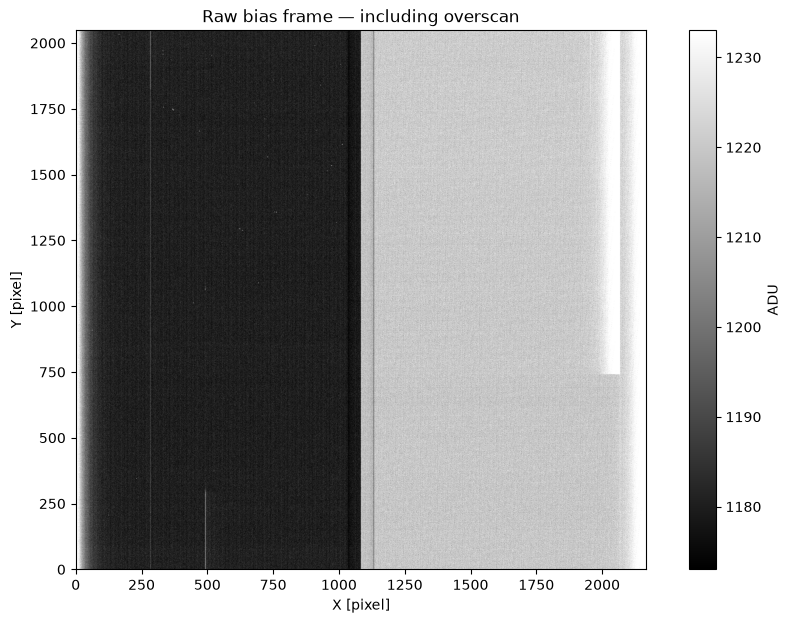

In [5]:
vmin, vmax = np.percentile(raw_bias, [5, 95])

plt.figure(figsize=(11, 7))

plt.imshow(
    raw_bias,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Raw bias frame — including overscan")

plt.colorbar(label="ADU")

plt.show()

In [6]:
overscan1 = raw_bias[:, 1044:1084]
overscan2 = raw_bias[:, 1084:1124]

print("Overscan 1 shape:", overscan1.shape)
print("Overscan 2 shape:", overscan2.shape)

Overscan 1 shape: (2048, 40)
Overscan 2 shape: (2048, 40)


In [7]:
overscan_level1 = np.median(overscan1, axis=1)
overscan_level2 = np.median(overscan2, axis=1)

print(overscan_level1.shape)
print(overscan_level2.shape)

(2048,)
(2048,)


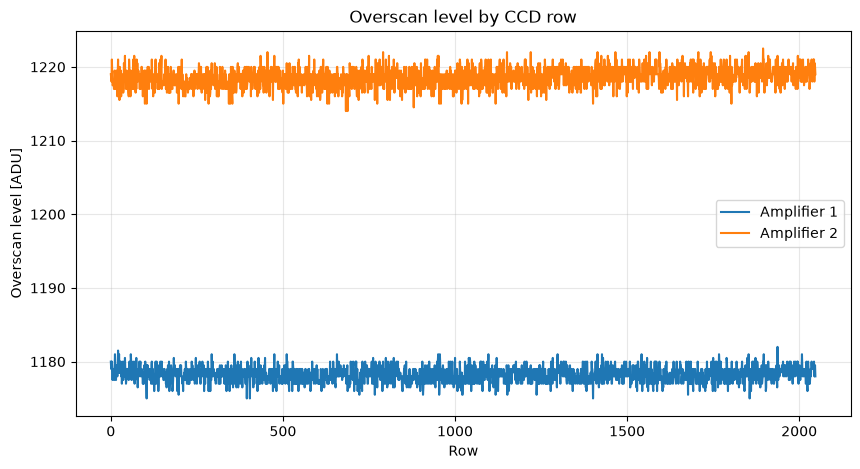

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(overscan_level1, label="Amplifier 1")
plt.plot(overscan_level2, label="Amplifier 2")

plt.xlabel("Row")
plt.ylabel("Overscan level [ADU]")
plt.title("Overscan level by CCD row")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [9]:
def overscan_correct_and_trim(data):
    """
    Perform row-by-row overscan correction for the two CCD amplifiers
    and return the trimmed 2048 x 2048 detector image.

    Parameters
    ----------
    data : numpy.ndarray
        Raw CCD image with shape (2048, 2168).

    Returns
    -------
    corrected : numpy.ndarray
        Overscan-corrected and trimmed CCD image.
    """

    # -------------------------
    # Amplifier 1
    # -------------------------

    # Useful detector area: FITS TSEC11 = [11:1034,1:2048]
    amp1 = data[:, 10:1034].astype(float)

    # Overscan: FITS BSEC11 = [1045:1084,1:2048]
    overscan1 = data[:, 1044:1084].astype(float)

    # Median overscan for every CCD row
    level1 = np.median(overscan1, axis=1, keepdims=True)

    # Correct amplifier 1
    amp1_corrected = amp1 - level1


    # -------------------------
    # Amplifier 2
    # -------------------------

    # Useful detector area: FITS TSEC12 = [1135:2158,1:2048]
    amp2 = data[:, 1134:2158].astype(float)

    # Overscan: FITS BSEC12 = [1085:1124,1:2048]
    overscan2 = data[:, 1084:1124].astype(float)

    level2 = np.median(overscan2, axis=1, keepdims=True)

    amp2_corrected = amp2 - level2


    # Join the two amplifiers
    corrected = np.hstack([
        amp1_corrected,
        amp2_corrected
    ])

    return corrected

In [10]:
corrected_bias = overscan_correct_and_trim(raw_bias)

print("Raw shape:", raw_bias.shape)
print("Corrected shape:", corrected_bias.shape)

Raw shape: (2048, 2168)
Corrected shape: (2048, 2048)


In [11]:
print("RAW BIAS")
print("Median:", np.median(raw_bias))
print("Std:", np.std(raw_bias))

print()

print("OVERSCAN-CORRECTED BIAS")
print("Median:", np.median(corrected_bias))
print("Std:", np.std(corrected_bias))

RAW BIAS
Median: 1209.0
Std: 1494.5607185950587

OVERSCAN-CORRECTED BIAS
Median: 2.5
Std: 1537.044619290734


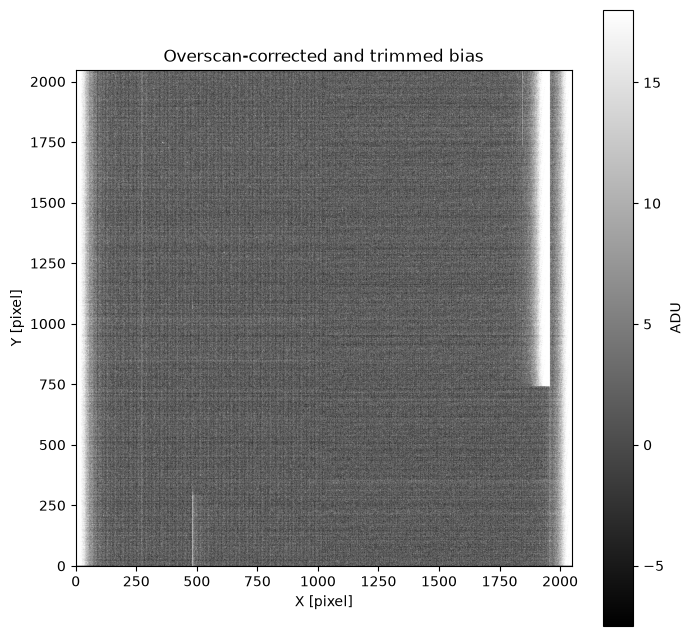

In [12]:
vmin, vmax = np.percentile(corrected_bias, [5, 95])

plt.figure(figsize=(8, 8))

plt.imshow(
    corrected_bias,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Overscan-corrected and trimmed bias")

plt.colorbar(label="ADU")

plt.show()

In [13]:
processed_biases = []

for filename in bias_files:

    hdu_index = get_image_hdu(filename)

    with fits.open(filename) as hdul:
        data = hdul[hdu_index].data.astype(float)

    corrected = overscan_correct_and_trim(data)

    processed_biases.append(corrected)

processed_biases = np.array(processed_biases)

print("Bias stack shape:", processed_biases.shape)

Bias stack shape: (10, 2048, 2048)


In [14]:
master_bias = np.median(processed_biases, axis=0)

print("Master Bias shape:", master_bias.shape)

print(f"Minimum : {np.min(master_bias):.3f} ADU")
print(f"Maximum : {np.max(master_bias):.3f} ADU")
print(f"Mean    : {np.mean(master_bias):.3f} ADU")
print(f"Median  : {np.median(master_bias):.3f} ADU")
print(f"Std     : {np.std(master_bias):.3f} ADU")

Master Bias shape: (2048, 2048)
Minimum : -194.250 ADU
Maximum : 61501.000 ADU
Mean    : 43.050 ADU
Median  : 2.500 ADU
Std     : 1536.393 ADU


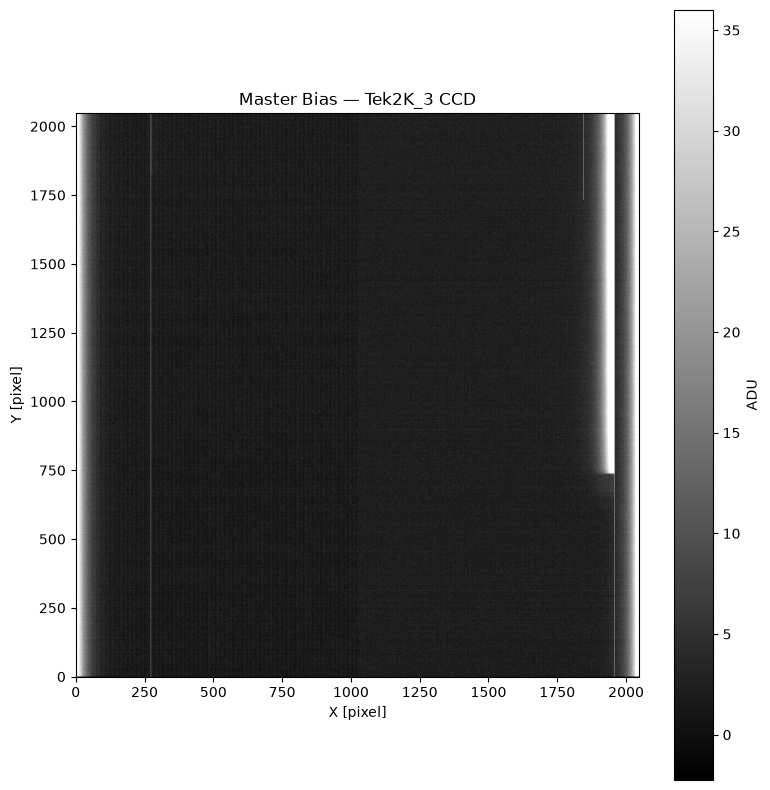

In [16]:
vmin, vmax = np.percentile(master_bias, [2, 98])

plt.figure(figsize=(8, 8))

plt.imshow(
    master_bias,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Master Bias — Tek2K_3 CCD")
plt.colorbar(label="ADU")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "master_bias.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [17]:
master_header = fits.Header()

master_header["IMAGETYP"] = "MASTER_BIAS"
master_header["NCOMBINE"] = len(bias_files)
master_header["DETECTOR"] = "Tek2K_3"
master_header["CCDSUM"] = "1 1"
master_header["HISTORY"] = "Overscan corrected using BSEC11 and BSEC12"
master_header["HISTORY"] = "Trimmed using TSEC11 and TSEC12"
master_header["HISTORY"] = "Combined using median"

master_bias_path = PRODUCTS_DIR / "master_bias.fits"

fits.writeto(
    master_bias_path,
    master_bias.astype(np.float32),
    header=master_header,
    overwrite=True
)

print("Saved:")
print(master_bias_path)

Saved:
C:\Users\rodri\NoirLab\products\master_bias.fits


In [18]:
with fits.open(master_bias_path) as hdul:
    hdul.info()

    test_master = hdul[0].data

print(test_master.shape)
print(np.median(test_master))

Filename: C:\Users\rodri\NoirLab\products\master_bias.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      12   (2048, 2048)   float32   
(2048, 2048)
2.5


In [20]:
mean_clip, median_clip, std_clip = sigma_clipped_stats(
    master_bias,
    sigma=3.0,
    maxiters=5
)

mad = mad_std(master_bias, ignore_nan=True)

print("=== Robust statistics ===")
print(f"Sigma-clipped mean   : {mean_clip:.3f} ADU")
print(f"Sigma-clipped median : {median_clip:.3f} ADU")
print(f"Sigma-clipped std    : {std_clip:.3f} ADU")
print(f"MAD std              : {mad:.3f} ADU")

=== Robust statistics ===
Sigma-clipped mean   : 2.379 ADU
Sigma-clipped median : 2.250 ADU
Sigma-clipped std    : 2.405 ADU
MAD std              : 2.595 ADU


In [21]:
percentiles = [
    0,
    0.01,
    0.1,
    1,
    5,
    50,
    95,
    99,
    99.9,
    99.99,
    100
]

values = np.percentile(master_bias, percentiles)

for p, value in zip(percentiles, values):
    print(f"{p:6.2f}% : {value:10.3f} ADU")

  0.00% :   -194.250 ADU
  0.01% :     -6.250 ADU
  0.10% :     -4.500 ADU
  1.00% :     -3.000 ADU
  5.00% :     -1.250 ADU
 50.00% :      2.500 ADU
 95.00% :     16.750 ADU
 99.00% :     47.750 ADU
 99.90% :     86.000 ADU
 99.99% :  61499.250 ADU
100.00% :  61501.000 ADU


In [22]:
thresholds = [20, 50, 100, 500, 1000, 10000]

print("Pixels far from the master-bias median:\n")

for threshold in thresholds:
    mask = np.abs(master_bias - median_clip) > threshold
    n_pixels = np.sum(mask)
    percentage = 100 * n_pixels / master_bias.size

    print(
        f"> {threshold:5d} ADU : "
        f"{n_pixels:8d} pixels "
        f"({percentage:.5f} %)"
    )

Pixels far from the master-bias median:

>    20 ADU :   160703 pixels (3.83146 %)
>    50 ADU :    28157 pixels (0.67132 %)
>   100 ADU :     3616 pixels (0.08621 %)
>   500 ADU :     3579 pixels (0.08533 %)
>  1000 ADU :     3579 pixels (0.08533 %)
> 10000 ADU :     2620 pixels (0.06247 %)


In [23]:
max_position = np.unravel_index(
    np.nanargmax(master_bias),
    master_bias.shape
)

min_position = np.unravel_index(
    np.nanargmin(master_bias),
    master_bias.shape
)

print("Maximum:")
print(" Position:", max_position)
print(" Value:", master_bias[max_position], "ADU")

print()

print("Minimum:")
print(" Position:", min_position)
print(" Value:", master_bias[min_position], "ADU")

Maximum:
 Position: (np.int64(1026), np.int64(1958))
 Value: 61501.0 ADU

Minimum:
 Position: (np.int64(0), np.int64(2047))
 Value: -194.25 ADU


In [24]:
y, x = max_position

pixel_values = processed_biases[:, y, x]

print("Value of the maximum pixel in every bias:\n")

for i, value in enumerate(pixel_values, start=1):
    print(f"Bias {i:02d}: {value:.2f} ADU")

Value of the maximum pixel in every bias:

Bias 01: 61501.00 ADU
Bias 02: 61501.50 ADU
Bias 03: 61501.00 ADU
Bias 04: 61496.00 ADU
Bias 05: 61502.50 ADU
Bias 06: 61501.50 ADU
Bias 07: 61501.50 ADU
Bias 08: 61498.50 ADU
Bias 09: 61496.50 ADU
Bias 10: 61498.50 ADU


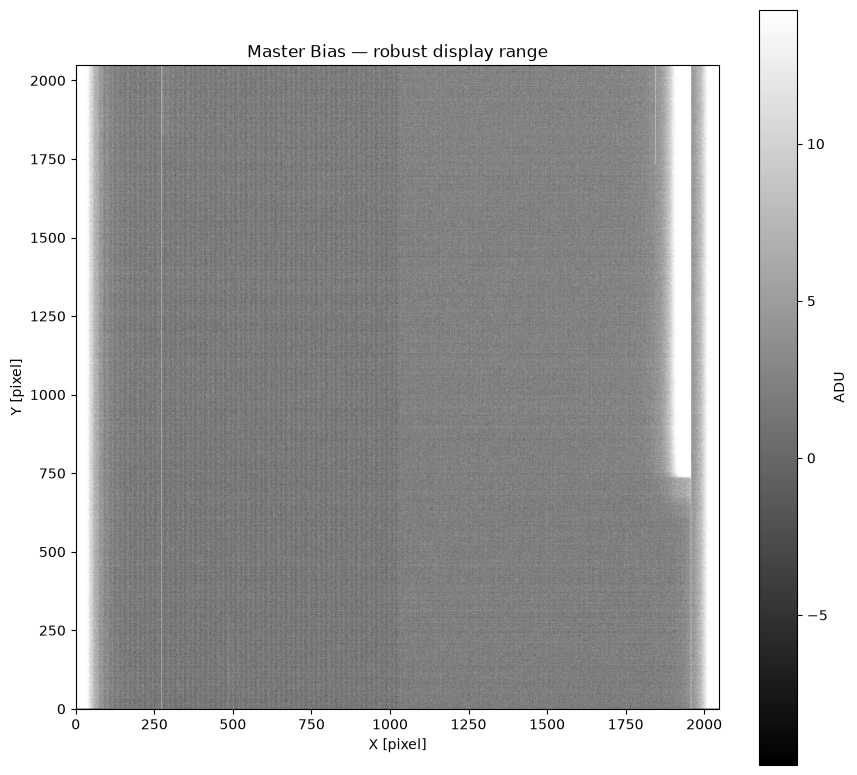

In [25]:
vmin = median_clip - 5 * std_clip
vmax = median_clip + 5 * std_clip

plt.figure(figsize=(9, 8))

plt.imshow(
    master_bias,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Master Bias — robust display range")

plt.tight_layout()
plt.show()

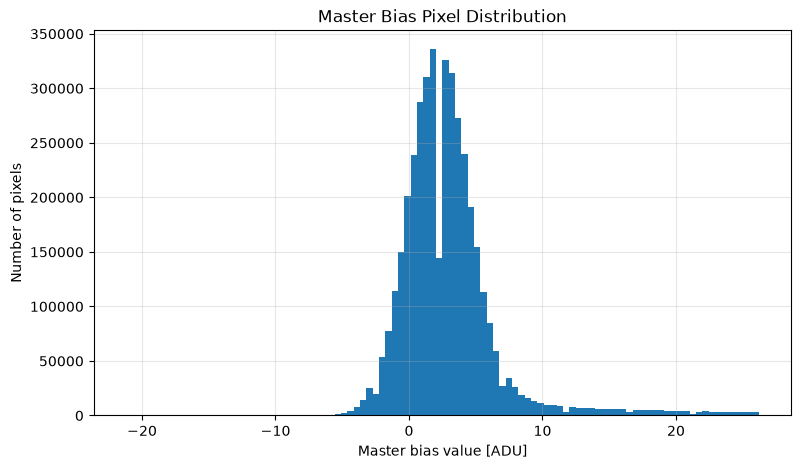

In [26]:
good_pixels = (
    (master_bias > median_clip - 10 * std_clip) &
    (master_bias < median_clip + 10 * std_clip)
)

plt.figure(figsize=(9, 5))

plt.hist(
    master_bias[good_pixels].ravel(),
    bins=100
)

plt.xlabel("Master bias value [ADU]")
plt.ylabel("Number of pixels")
plt.title("Master Bias Pixel Distribution")

plt.grid(alpha=0.3)
plt.show()

In [27]:
amp1_master = master_bias[:, :1024]
amp2_master = master_bias[:, 1024:]

_, med1, std1 = sigma_clipped_stats(
    amp1_master,
    sigma=3,
    maxiters=5
)

_, med2, std2 = sigma_clipped_stats(
    amp2_master,
    sigma=3,
    maxiters=5
)

print("Amplifier 1")
print(f"Median: {med1:.3f} ADU")
print(f"Std:    {std1:.3f} ADU")

print()

print("Amplifier 2")
print(f"Median: {med2:.3f} ADU")
print(f"Std:    {std2:.3f} ADU")

Amplifier 1
Median: 2.000 ADU
Std:    2.323 ADU

Amplifier 2
Median: 2.750 ADU
Std:    2.448 ADU


In [28]:
# Extremely high pixels in the master bias
high_mask = master_bias > 60000

n_high = np.sum(high_mask)
percentage_high = 100 * n_high / master_bias.size

print(f"Pixels > 60000 ADU: {n_high}")
print(f"Fraction of detector: {percentage_high:.6f} %")

Pixels > 60000 ADU: 2618
Fraction of detector: 0.062418 %


In [29]:
coords = np.argwhere(high_mask)

if len(coords) > 0:
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    print("Spatial extent of high-value pixels:")
    print(f"X: {x_min} -> {x_max}")
    print(f"Y: {y_min} -> {y_max}")

Spatial extent of high-value pixels:
X: 1957 -> 1958
Y: 739 -> 2047


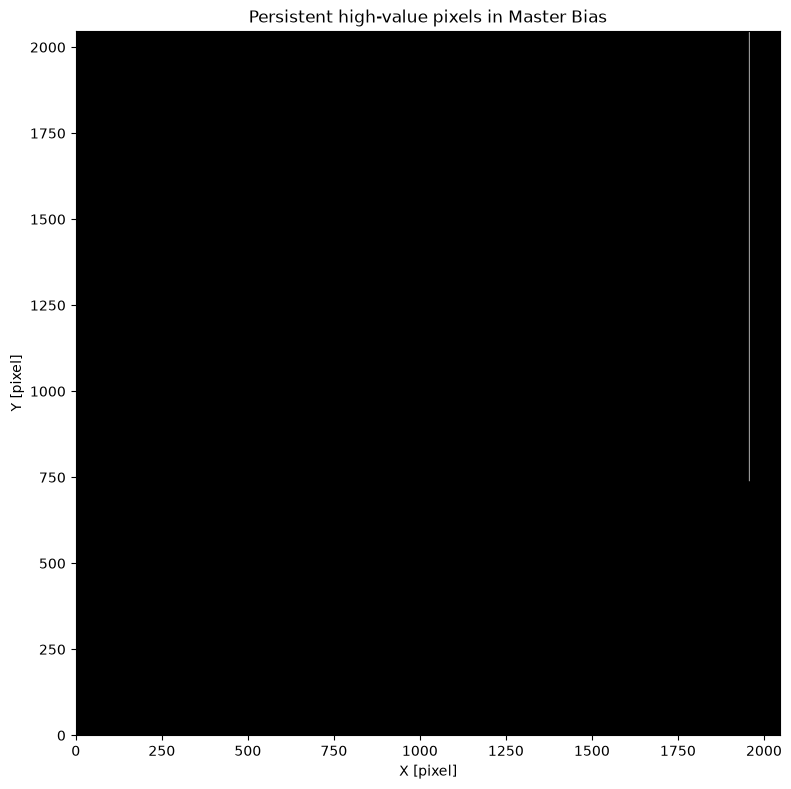

In [30]:
plt.figure(figsize=(8, 8))

plt.imshow(
    high_mask,
    origin="lower",
    cmap="gray"
)

plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Persistent high-value pixels in Master Bias")

plt.tight_layout()
plt.show()